In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('libraries imported')


libraries imported


In [2]:
bank_data=pd.read_excel(r"C:\Users\VIJI\Downloads\Bank_Personal_Loan_Modelling (1).xlsx")
data=bank_data.copy()


In [3]:
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [4]:
print('shape of data{}'.format(data.shape))
print('number of rows{}'.format(data.shape[0]))
print('number of columns:{}'.format(data.shape[1]))

shape of data(5000, 14)
number of rows5000
number of columns:14


In [5]:
data.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [6]:
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [7]:
## missings and duplicates values

print(data.isna().sum().sort_values(ascending=False))
print('duplicate values in data are ',data.duplicated().sum())
print('duplicates dropped')
      

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64
duplicate values in data are  0
duplicates dropped


In [8]:
data.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937913,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747666,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [9]:
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [10]:
## dropping unnecessary columns ID and Zip code
data.drop(columns=['ID','ZIP Code'],axis=1,inplace=True)

In [14]:
# Create counts of df for plotting categorical variables
loan = np.unique(data['Personal Loan'], return_counts=True)
print('loan = {}\n'.format(loan))


loan = (array([0, 1], dtype=int64), array([4520,  480], dtype=int64))



In [16]:
# Create fontdicts for formatting figure text
axtitle_dict = {'family': 'serif','color':  'darkred','weight': 'bold','size': 16}
axlab_dict = {'family': 'serif', 'color': 'black','size': 14}


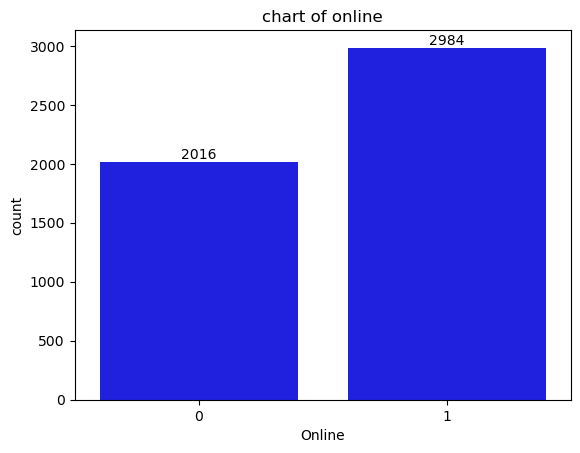

In [11]:
ax=sns.countplot(x='Online',data=data,color='blue')
plt.title("chart of online")
for bars in ax.containers:
    ax.bar_label(bars)
    

In [12]:
plt.show()

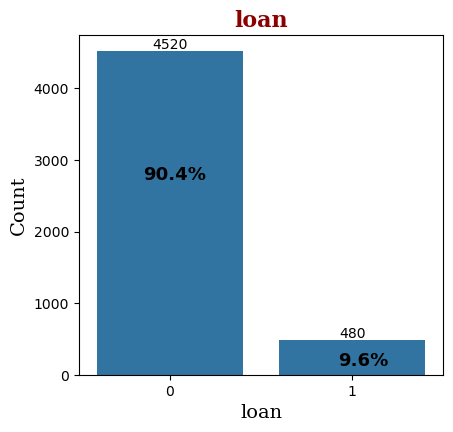

In [18]:
# Display a frequency distribution for Personal Loan. 
fig = plt.figure(figsize=[16,15]);
ax1 = fig.add_subplot(3, 3, 2);
sns.barplot(x=list(loan[0]), y=list(loan[1]), ax=ax1 );
ax1.text(0.2, 2800, '{}%' .format(str(round(loan[1][0]/sum(loan[1])*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
ax1.text(1.2, 200, '{}%' .format(str(round(loan[1][1]/sum(loan[1])*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
ax1.set_title('loan', fontdict=axtitle_dict);
ax1.set_xlabel('loan', fontdict=axlab_dict);
ax1.set_ylabel('Count', fontdict=axlab_dict);
ax1.bar_label(ax1.containers[0])
plt.show()

In [22]:
categ_columns=[]
for col in data.columns:
    if data[col].nunique()<=5:
        if col!='personal Loan':
            categ_columns.append(col)
print('categ numericals columns are{}'.format(categ_columns))
    

categ numericals columns are['Family', 'Education', 'Personal Loan', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


In [24]:
Num_cols = [col for col in data.columns if col not in categ_columns]
print('numericals columns are {}'.format(Num_cols)) 
Num_cols.pop()
Num_cols


numericals columns are ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']


['Age', 'Experience', 'Income', 'CCAvg']

In [28]:
# Create counts of df for plotting categorical variables
Online_account = np.unique(data['Online'], return_counts=True)
print('Online_account = {}\n'.format(Online_account))


Online_account = (array([0, 1], dtype=int64), array([2016, 2984], dtype=int64))



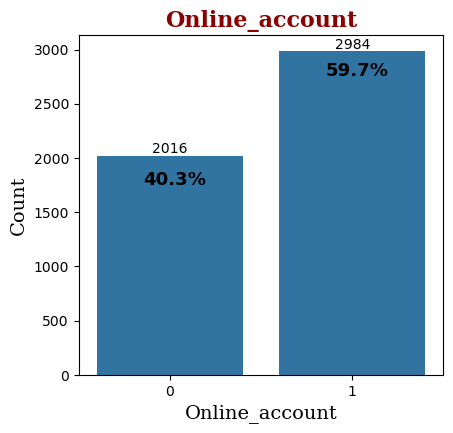

In [30]:
fig = plt.figure(figsize=[16,15]);
ax1 = fig.add_subplot(3, 3, 2);
sns.barplot(x=list(Online_account[0]), y=list(Online_account[1]), ax=ax1 );
ax1.text(0.2, 1800, '{}%' .format(str(round(Online_account[1][0]/sum(Online_account[1])*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
ax1.text(1.2, 2800, '{}%' .format(str(round(Online_account[1][1]/sum(Online_account[1])*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
ax1.set_title('Online_account', fontdict=axtitle_dict);
ax1.set_xlabel('Online_account', fontdict=axlab_dict);
ax1.set_ylabel('Count', fontdict=axlab_dict);
ax1.bar_label(ax1.containers[0])
plt.show()


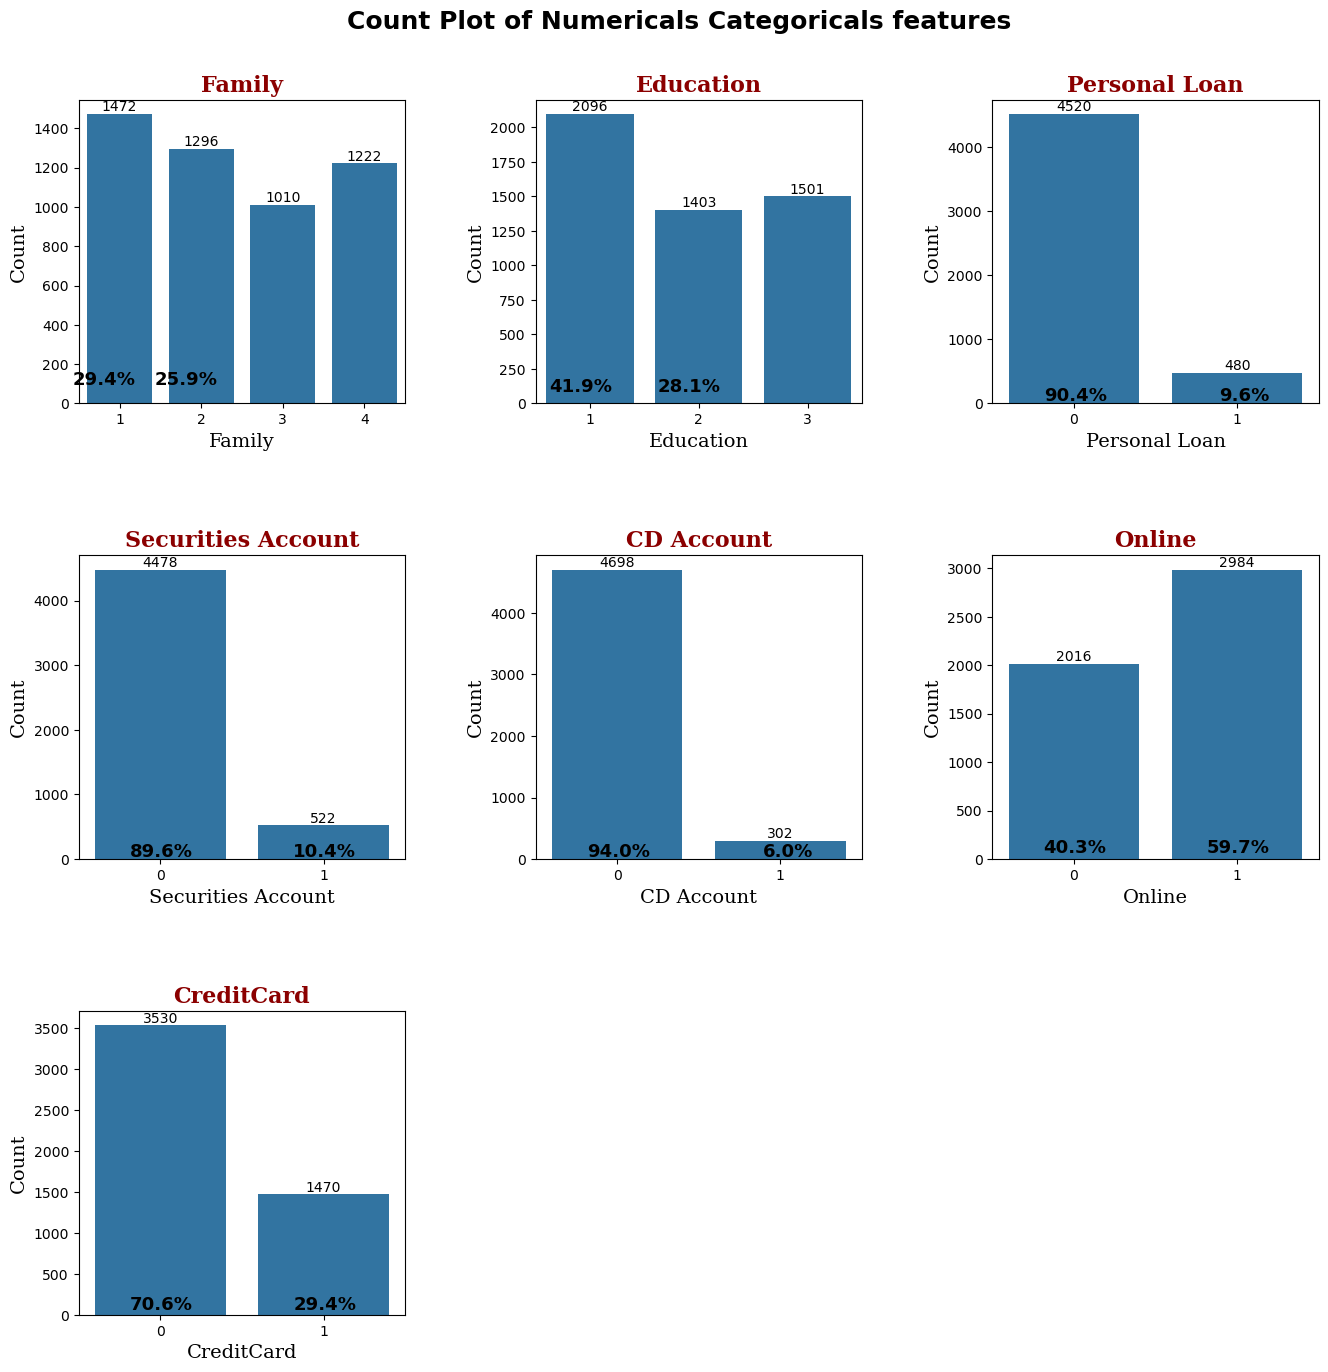

In [32]:
# Unvariate Analysis
fig = plt.figure(figsize=[16,15])
fig.suptitle('Count Plot of Numericals Categoricals features', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i , columns in enumerate(categ_columns):
    input = np.unique(data[columns] , return_counts = True)
    col= 'input'
    ax1 = fig.add_subplot(3, 3, i+1);
    ax1 = sns.barplot(x=list(eval(f'{col}[0]')), y=list(eval(f'{col}[1]')))
    #The below two lines of codes are used for percentage values.
    ax1.text(0.2, 120, '{}%' .format(str(round(eval(f'{col}[1][0]')/sum(eval(f'{col}[1]'))*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
    ax1.text(1.2, 120, '{}%' .format(str(round(eval(f'{col}[1][1]')/sum(eval(f'{col}[1]'))*100,1))), ha='right', va='center', size=13, fontdict={'weight': 'bold'})
    ax1.set_title(f'{columns}', fontdict=axtitle_dict)
    ax1.set_xlabel(f'{columns}', fontdict=axlab_dict)
    ax1.set_ylabel('Count', fontdict=axlab_dict)
    ax1.bar_label(ax1.containers[0])


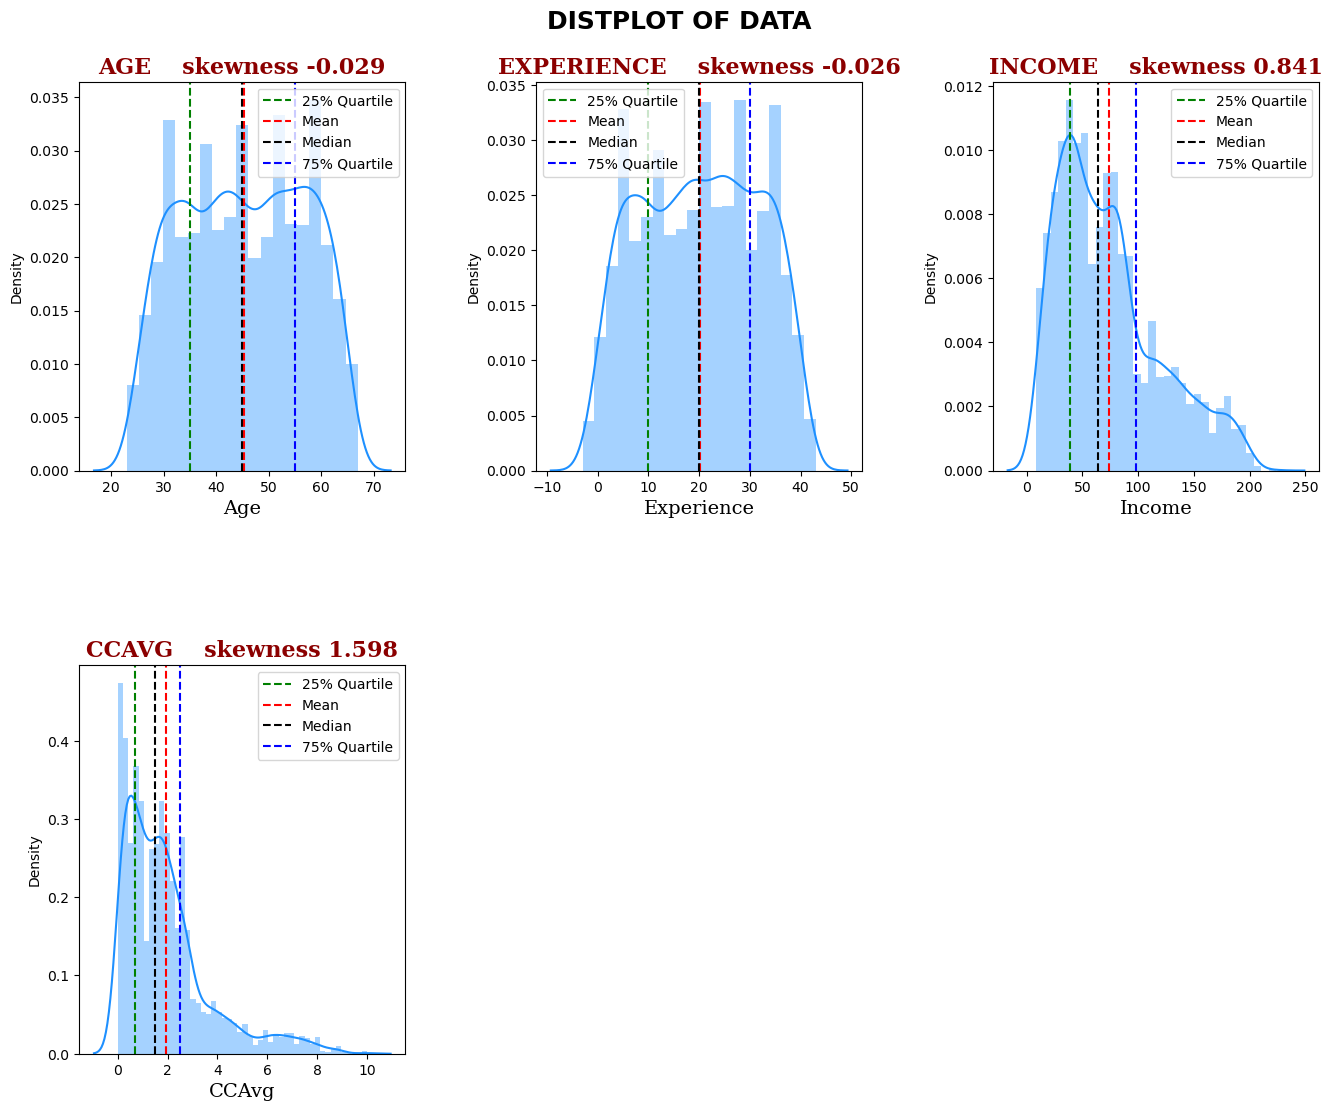

In [34]:
# Distplot
# Create figure with 3 x 3 grid of subplots
fig = plt.figure(figsize=[16,12])
fig.suptitle('DISTPLOT OF DATA', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i ,col in enumerate(Num_cols):
    ax = fig.add_subplot(2, 3, i+1)
    ax = sns.distplot(data[col],  color='dodgerblue')
    ax.axvline(data[col].quantile(q=0.25),color='green',linestyle='--',label='25% Quartile')
    ax.axvline(data[col].mean(),color='red',linestyle='--',label='Mean')
    ax.axvline(data[col].median(),color='black',linestyle='--',label='Median')
    ax.axvline(data[col].quantile(q=0.75),color='blue',linestyle='--',label='75% Quartile')
    # ax.text('skewness: {}' .format(str(round(df[col].skew(),3))), ha='right', va='center', size=11)
    ax.set_xlabel(f'{col}', fontdict=axlab_dict)
    ax.set_title(f'{col.upper()}    skewness {round(data[col].skew(),3)}', fontdict=axtitle_dict)
    ax.legend(fontsize=10) 


In [36]:
# Outliers Detection
# Check of outliers by applying the IQR method checking if values are way outside the IQR borders.
# numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
data_num = data[Num_cols]
data_num.describe()

Q1 = data_num.quantile(0.25)
Q3 = data_num.quantile(0.75)
IQR = Q3 - Q1
IQR
((data_num < (Q1 - 1.5 * IQR)) | (data_num > (Q3 + 1.5 * IQR))).any()


Age           False
Experience    False
Income         True
CCAvg          True
dtype: bool

In [40]:
colours = ['forestgreen','dodgerblue','goldenrod', 'coral' , 'silver' , 'gold' , 'dodgerblue'];

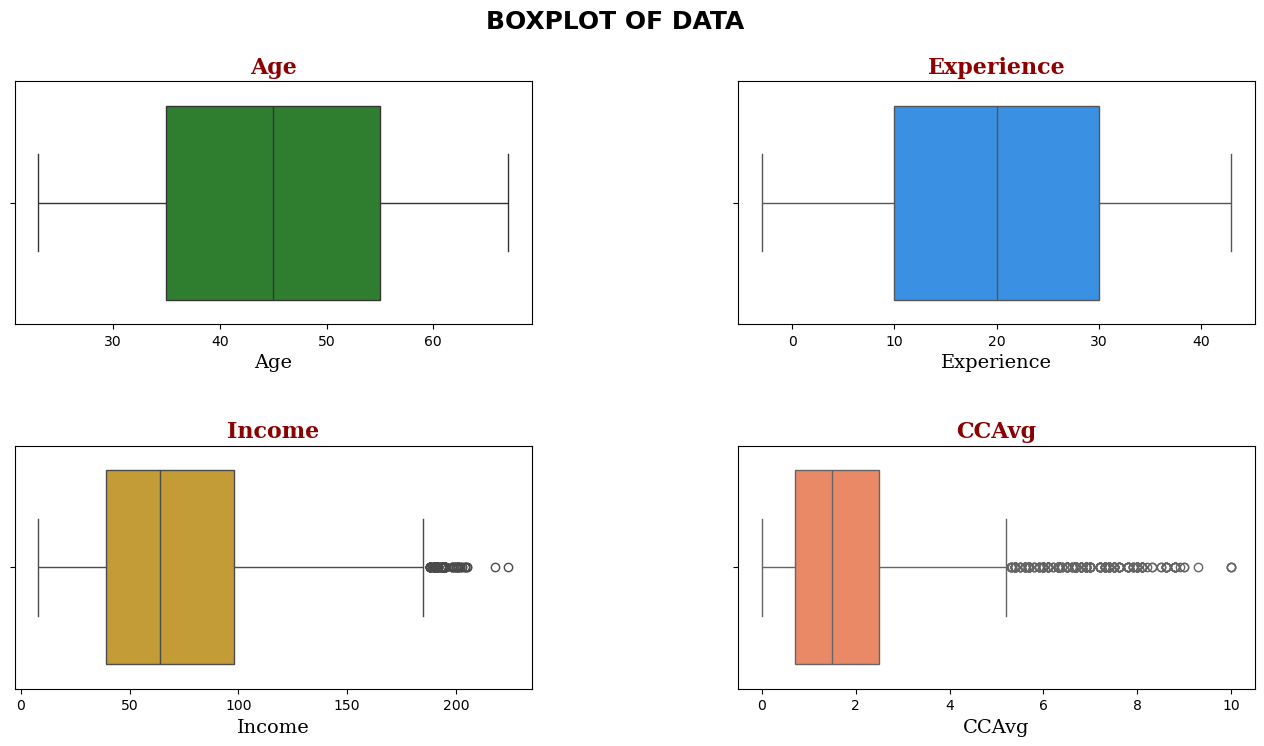

In [42]:
##Visualization of outliers using box plot

# Create figure with 3 x 3 grid of subplots
fig = plt.figure(figsize=[16,12])
fig.suptitle('BOXPLOT OF DATA', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i ,col in enumerate(Num_cols):  
    ax1 = fig.add_subplot(3, 2, i+1);
    ax1 = sns.boxplot(data = data, x=col ,  color= colours[i]);
 
    ax1.set_title(f'{col}', fontdict=axtitle_dict) 
    ax1.set_xlabel(f'{col}', fontdict=axlab_dict)


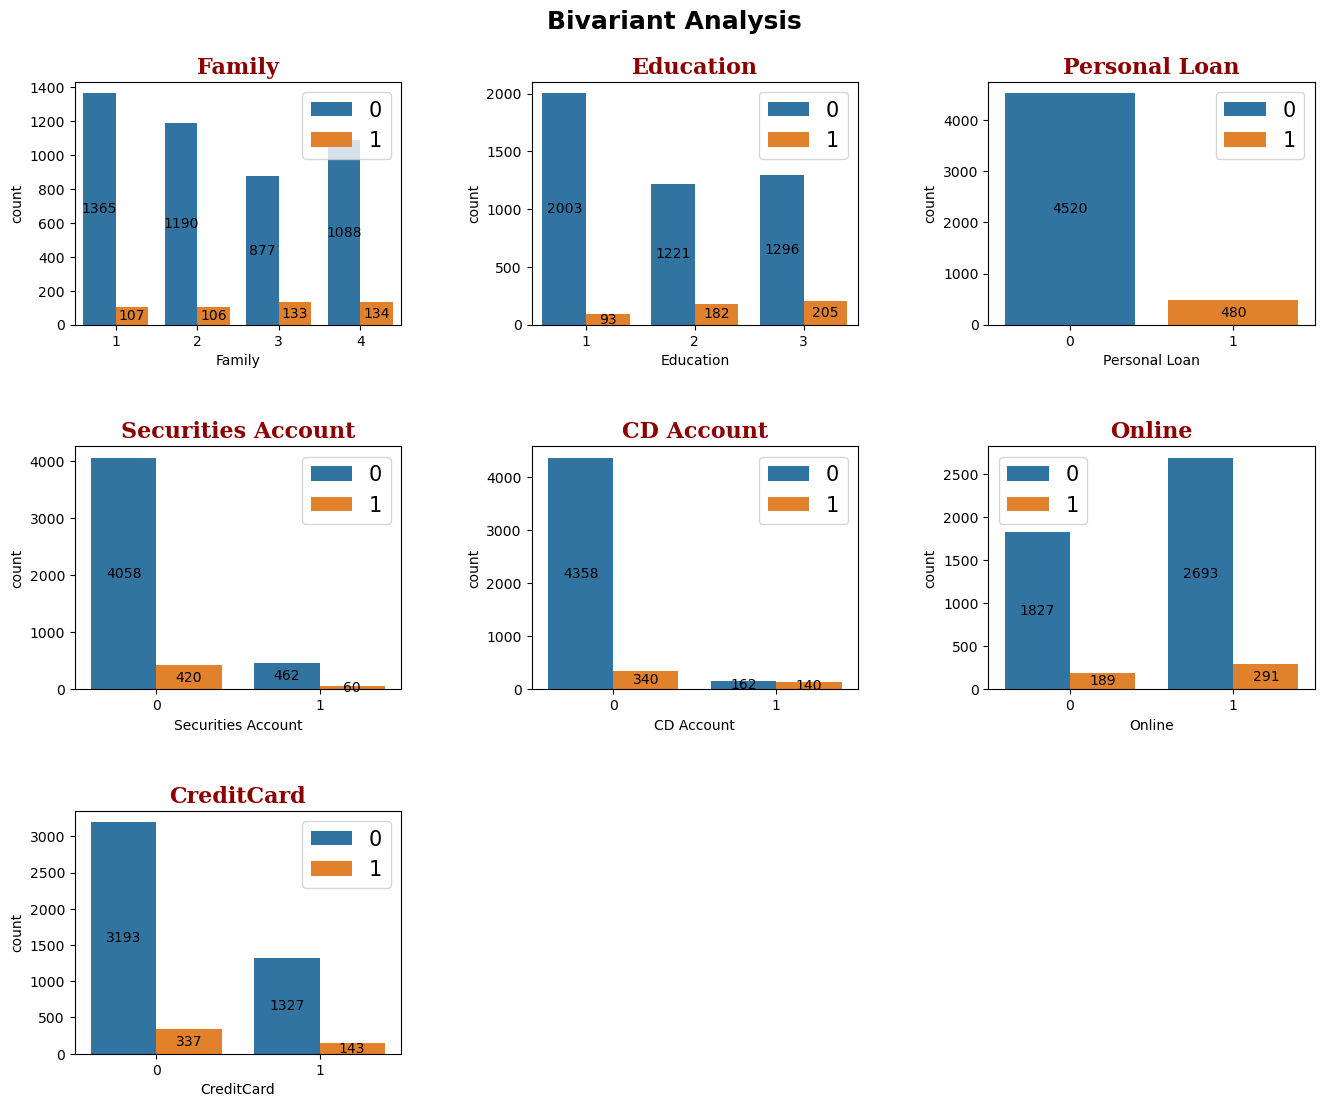

In [44]:
# Create figure with 3 x 3 grid of subplots
fig = plt.figure(figsize=[16,12])
fig.suptitle('Bivariant Analysis', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i ,col in enumerate(categ_columns):
    a = fig.add_subplot(3, 3, i+1)
    a=sns.countplot(x = data[col] , ax=a , hue = data['Personal Loan'] )
    a.set_title(col , fontdict=axtitle_dict)
    a.bar_label(a.containers[0] , label_type='center') 
    a.bar_label(a.containers[1] , label_type='center')
    a.legend(fontsize=15)

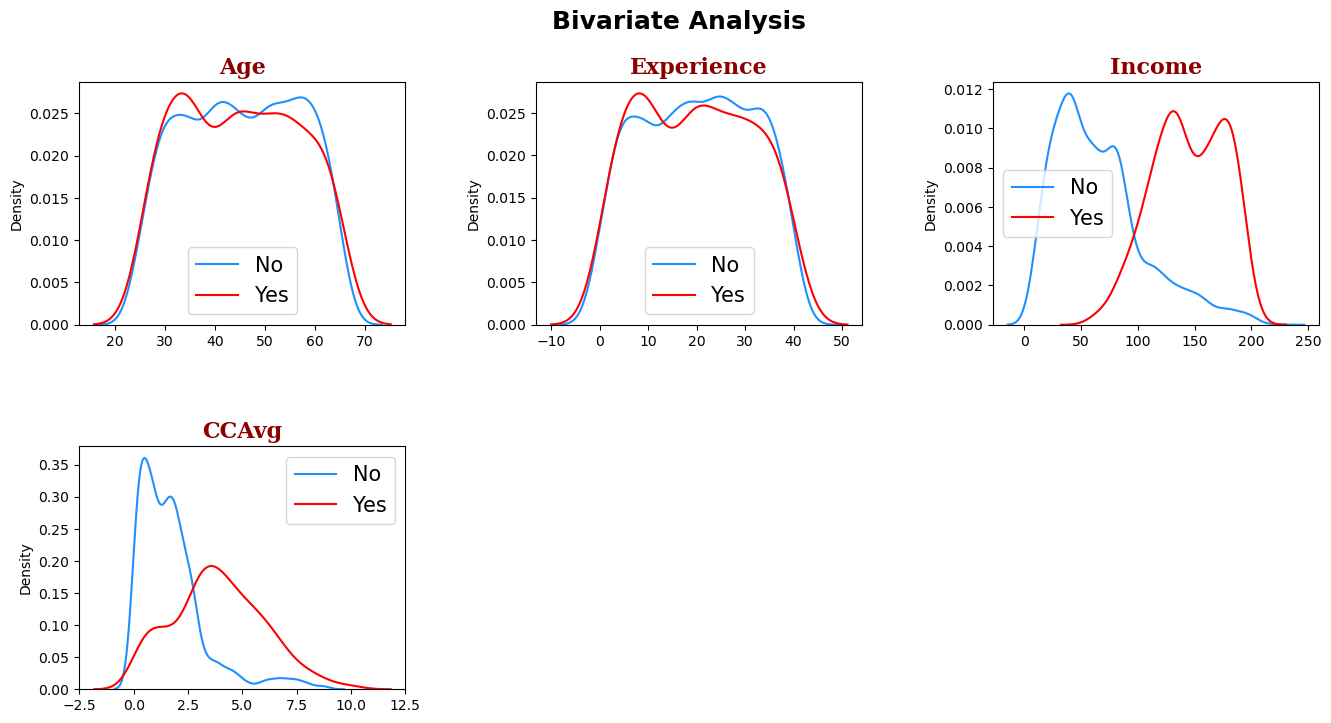

In [46]:
fig = plt.figure(figsize=[16,12])
fig.suptitle('Bivariate Analysis', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92);
fig.subplots_adjust(hspace=0.5, wspace=0.4);
for i ,col in enumerate(Num_cols):
    a = fig.add_subplot(3, 3, i+1)
    
    sns.distplot(x =data[data['Personal Loan']==0][col],  color='dodgerblue' , ax=a ,  hist =False)
    sns.distplot(x =data[data['Personal Loan']==1][col],  color='red' , ax=a , hist =False) 
    a.set_title(col , fontdict=axtitle_dict)    
    labels = ['No' , 'Yes']
    a.legend( labels  , fontsize = 15)


     


In [50]:
dum_data = pd.get_dummies(data , columns = categ_columns)
dum_data.head()


,Age,Experience,Income,CCAvg,Mortgage,Family_1,Family_2,Family_3,Family_4,Education_1,...,Personal Loan_0,Personal Loan_1,Securities Account_0,Securities Account_1,CD Account_0,CD Account_1,Online_0,Online_1,CreditCard_0,CreditCard_1
0,25,1,49,1.6,0,False,False,False,True,True,...,True,False,False,True,True,False,True,False,True,False
1,45,19,34,1.5,0,False,False,True,False,True,...,True,False,False,True,True,False,True,False,True,False
2,39,15,11,1.0,0,True,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
3,35,9,100,2.7,0,True,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
4,35,8,45,1.0,0,False,False,False,True,False,...,True,False,True,False,True,False,True,False,False,True


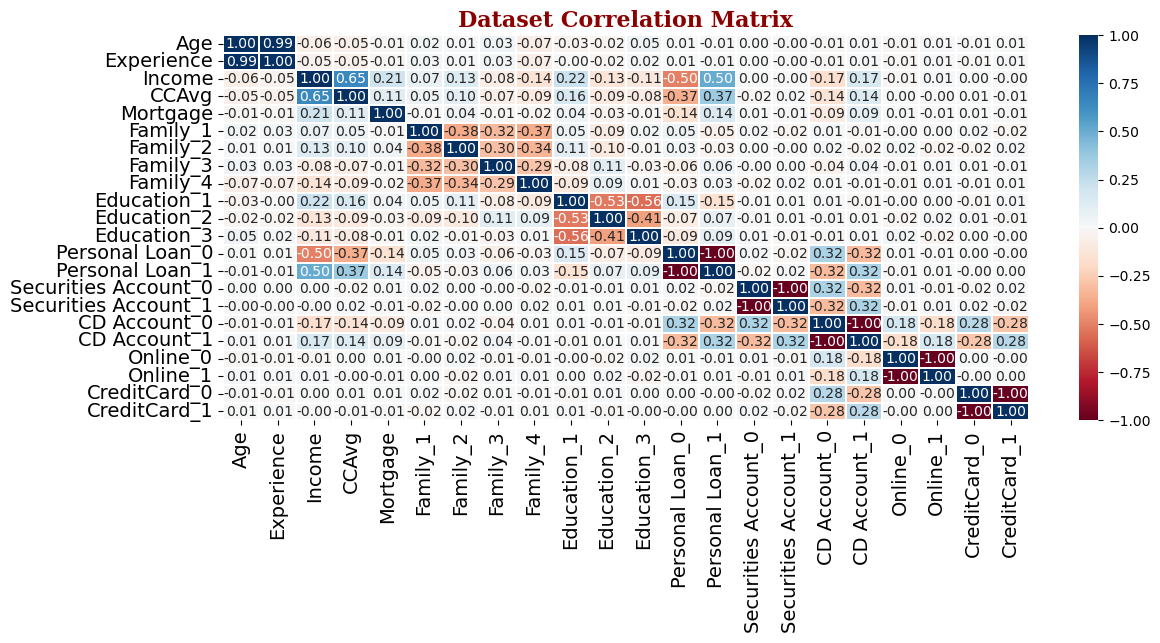

In [52]:
# Heatmap
# Plot correlation matrix heatmap
fig, ax = plt.subplots(figsize=[13,5])
sns.heatmap(dum_data.corr(), ax=ax,  annot=True, linewidths=0.05, fmt= '.2f',cmap='RdBu')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_title('Dataset Correlation Matrix', fontdict=axtitle_dict)
fig.show()


In [54]:
data.dtypes

Age                     int64
Experience              int64
Income                  int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

In [56]:
data.head(2)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
